# Modeling the Evolution of Wealth
## A Fokker–Planck PDE Approach to Portfolio Risk

**Authors:** Arche & Bartłomiej Mielcarz
**Course:** Partial Differential Equations — Project (June 2026)

This notebook accompanies the project report. It implements a finite-difference
solver for the **Fokker–Planck (forward Kolmogorov) equation** governing the
probability density of portfolio wealth under geometric Brownian motion (GBM),
validates it against the closed-form log-normal law and Monte-Carlo simulation,
and uses the propagated terminal density to compute goal-attainment probabilities
and tail-risk metrics (VaR, Expected Shortfall) across a range of asset allocations.

All code is self-contained: run the cells top to bottom.

In [1]:
%matplotlib inline
# ============================================================
#  Imports and global plotting configuration
# ============================================================
import os
import numpy as np
import scipy.sparse as ssp
from scipy.sparse.linalg import splu
from scipy.integrate import cumulative_trapezoid
from scipy.stats import norm
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
rng = np.random.default_rng(20260618)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9.5,
    "lines.linewidth": 1.8,
})

# Consistent colour palette across the report
C_ANA  = "#1b1b1b"   # analytical (black, dashed)
C_CN   = "#1f6feb"   # Crank–Nicolson
C_EXP  = "#e8590c"   # explicit FTCS
C_MC   = "#adb5bd"   # Monte-Carlo histogram
C_CONS = "#2f9e44"   # conservative allocation
C_BAL  = "#1971c2"   # balanced allocation
C_AGG  = "#d6336c"   # aggressive allocation

## 1. Market model and base-case parameters
Wealth $W_t$ follows geometric Brownian motion
$$ dW_t = \mu\,W_t\,dt + \sigma\,W_t\,dW_t, \qquad W_0\ \text{given}. $$
Parameters are annualised. The base case is a single risky portfolio; Section 9 builds
mixed equity/cash allocations on top of it. The Itô correction gives the **log-drift**
$\nu=\mu-\tfrac12\sigma^2$.

In [2]:
# --- Base-case (single-asset) parameters -----------------------------
W0    = 100.0     # initial wealth (currency units, e.g. kPLN)
mu    = 0.08      # expected (arithmetic) return per year
sigma = 0.18      # volatility per year
T     = 10.0      # investment horizon (years)

# --- Risky asset + risk-free building blocks (used for allocations) --
MU_EQ, SIG_EQ = 0.08, 0.18    # equity sleeve
RF            = 0.03          # risk-free rate (treated as volatility-free)

# --- Financial targets ----------------------------------------------
GOAL  = 200.0     # "double my money" target
FLOOR = 80.0      # capital-preservation floor (20% drawdown)

def log_drift(mu_, sig_):
    """Itô-corrected drift of log-wealth."""
    return mu_ - 0.5 * sig_**2

nu = log_drift(mu, sigma)
print(f"Base case:  mu={mu:.3f},  sigma={sigma:.3f},  nu = mu - sigma^2/2 = {nu:.5f}")
print(f"Median terminal wealth  W0*exp(nu*T) = {W0*np.exp(nu*T):8.2f}")
print(f"Mean   terminal wealth  W0*exp(mu*T) = {W0*np.exp(mu*T):8.2f}")

Base case:  mu=0.080,  sigma=0.180,  nu = mu - sigma^2/2 = 0.06380
Median terminal wealth  W0*exp(nu*T) =   189.27
Mean   terminal wealth  W0*exp(mu*T) =   222.55


## 2. Closed-form benchmark (the log-normal law)
Under GBM the log-wealth $Y_t=\ln W_t$ is **exactly Gaussian**,
$$ Y_t \sim \mathcal{N}\!\big(\ln W_0 + \nu t,\ \sigma^2 t\big), $$
so wealth is log-normal. These formulas are the ground truth for validating the solver,
and they yield closed-form risk metrics for the lower tail.

In [3]:
def gauss_logdensity(y, t, W0, mu, sig):
    """Exact density of Y = ln W at time t (Gaussian)."""
    nu_ = log_drift(mu, sig)
    m = np.log(W0) + nu_ * t
    v = sig**2 * t
    return np.exp(-(y - m)**2 / (2.0*v)) / np.sqrt(2.0*np.pi*v)

def lognormal_wealthdensity(W, t, W0, mu, sig):
    """Exact density of wealth W at time t (log-normal)."""
    nu_ = log_drift(mu, sig)
    m = np.log(W0) + nu_ * t
    v = sig**2 * t
    return np.exp(-(np.log(W) - m)**2 / (2.0*v)) / (W*np.sqrt(2.0*np.pi*v))

def analytic_metrics(W0, mu, sig, T, goal, floor, alpha=0.05):
    """Closed-form goal/tail metrics for the log-normal terminal law."""
    nu_ = log_drift(mu, sig)
    m = np.log(W0) + nu_*T
    s = sig*np.sqrt(T)                                  # std of log-wealth
    p_goal  = norm.cdf((m - np.log(goal)) / s)          # P(W_T >= goal)
    p_floor = norm.cdf((np.log(floor) - m) / s)         # P(W_T <= floor)
    p_loss  = norm.cdf((np.log(W0)  - m) / s)           # P(W_T <  W0)
    za = norm.ppf(alpha)
    var_w = np.exp(m + s*za)                            # alpha-quantile of wealth
    es_w  = np.exp(m + 0.5*s**2) * norm.cdf(za - s) / alpha   # E[W | W <= VaR]
    return dict(p_goal=p_goal, p_floor=p_floor, p_loss=p_loss,
                var_w=var_w, es_w=es_w,
                var_loss=(W0-var_w)/W0, es_loss=(W0-es_w)/W0,
                mean=W0*np.exp(mu*T), median=np.exp(m))

## 3. Finite-difference solver for the Fokker–Planck equation
In log-coordinates the Fokker–Planck equation has **constant coefficients**,
$$ \partial_t q = -\nu\,\partial_y q + \tfrac12\sigma^2\,\partial_y^2 q, \qquad y\in[y_{\min},y_{\max}], $$
with homogeneous Dirichlet data ($q=0$) on a domain wide enough that boundary mass is
negligible. Two schemes are implemented:

* **Explicit FTCS** — first order in time, conditionally stable ($\sigma^2\Delta t/\Delta y^2\le 1$);
* **Crank–Nicolson** — second order in time *and* space, unconditionally stable (default).

The (near-)point initial mass at $W_0$ is regularised by starting from the exact Gaussian
at a small time $t_0>0$, where it is smooth enough to resolve on the grid.

In [4]:
def make_loggrid(W0, mu, sig, T, n_std=7.0, N=1201):
    """Uniform log-wealth grid wide enough to contain the bulk of the terminal mass."""
    nu_ = log_drift(mu, sig)
    y0 = np.log(W0)
    mean_T = y0 + nu_*T
    half = n_std * sig*np.sqrt(T)
    y_lo = min(y0, mean_T) - half
    y_hi = max(y0, mean_T) + half
    return np.linspace(y_lo, y_hi, N)

def initial_condition(y, W0, mu, sig, t0):
    """Regularised initial state: exact Gaussian at small time t0."""
    return gauss_logdensity(y, t0, W0, mu, sig)

def solve_explicit(y, q0, nu_, sig, t0, T, dt):
    """Forward-time, central-space (FTCS) explicit scheme. Returns (q_T, diffusion_number)."""
    dy = y[1] - y[0]
    D  = 0.5*sig**2
    sd = D*dt/dy**2          # diffusion number  (stable iff <= 1/2)
    sa = nu_*dt/dy           # advection number
    nsteps = int(round((T - t0)/dt))
    q = q0.copy()
    for _ in range(nsteps):
        qn = q
        q = qn.copy()
        q[1:-1] = (qn[1:-1]
                   + sd*(qn[2:] - 2.0*qn[1:-1] + qn[:-2])
                   - 0.5*sa*(qn[2:] - qn[:-2]))
        q[0] = 0.0
        q[-1] = 0.0
    return q, sd

def _cn_operators(dy, nu_, sig, dt, M):
    """Tridiagonal Crank–Nicolson operators A q^{n+1} = B q^n on M interior nodes."""
    D  = 0.5*sig**2
    sd = D*dt/dy**2
    sa = nu_*dt/dy
    lowL, diaL, uppL = -(sd/2 + sa/4), (1.0 + sd), -(sd/2 - sa/4)
    lowR, diaR, uppR =  (sd/2 + sa/4), (1.0 - sd),  (sd/2 - sa/4)
    A = ssp.diags([np.full(M-1, lowL), np.full(M, diaL), np.full(M-1, uppL)],
                 [-1, 0, 1], format="csc")
    B = ssp.diags([np.full(M-1, lowR), np.full(M, diaR), np.full(M-1, uppR)],
                 [-1, 0, 1], format="csr")
    return A, B

def solve_cn(y, q0, nu_, sig, t0, T, dt, record_times=None):
    """Crank–Nicolson scheme. Optionally records density snapshots at record_times."""
    dy = y[1] - y[0]
    M  = len(y) - 2
    A, B = _cn_operators(dy, nu_, sig, dt, M)
    lu = splu(A)
    q = q0.copy()
    nsteps = int(round((T - t0)/dt))
    snaps, targets, ti, t = {}, sorted(record_times) if record_times else [], 0, t0
    for _ in range(nsteps):
        q[1:-1] = lu.solve(B.dot(q[1:-1]))
        q[0] = 0.0
        q[-1] = 0.0
        t += dt
        while ti < len(targets) and t >= targets[ti] - 1e-9:
            snaps[targets[ti]] = q.copy()
            ti += 1
    return q, snaps

## 4. Validation against the closed-form solution
Starting from the regularised state at $t_0=0.05$ yr, we march to $T=10$ yr and compare
both schemes to the exact Gaussian. We also check that the scheme conserves total
probability $\int q\,dy \approx 1$.

In [5]:
t0 = 0.05
y  = make_loggrid(W0, mu, sigma, T, n_std=7.0, N=1601)
dy = y[1] - y[0]
q0 = initial_condition(y, W0, mu, sigma, t0)

dt_cn  = 0.01
dt_exp = 0.4 * dy**2 / sigma**2          # CFL-safe: diffusion number = 0.4 < 0.5

qT_cn,  _  = solve_cn(y, q0, nu, sigma, t0, T, dt_cn)
qT_exp, sd = solve_explicit(y, q0, nu, sigma, t0, T, dt_exp)
qT_ana     = gauss_logdensity(y, T, W0, mu, sigma)

mass    = np.trapezoid(qT_cn, y)
err_cn  = np.max(np.abs(qT_cn  - qT_ana))
err_exp = np.max(np.abs(qT_exp - qT_ana))
print(f"explicit diffusion number  sd = {sd:.3f}   (stable if <= 0.5)")
print(f"CN total probability   ∫ q dy = {mass:.6f}")
print(f"max |CN  - exact|             = {err_cn:.3e}")
print(f"max |FTCS - exact|            = {err_exp:.3e}")

explicit diffusion number  sd = 0.200   (stable if <= 0.5)
CN total probability   ∫ q dy = 1.000000
max |CN  - exact|             = 1.766e-05
max |FTCS - exact|            = 1.400e-05


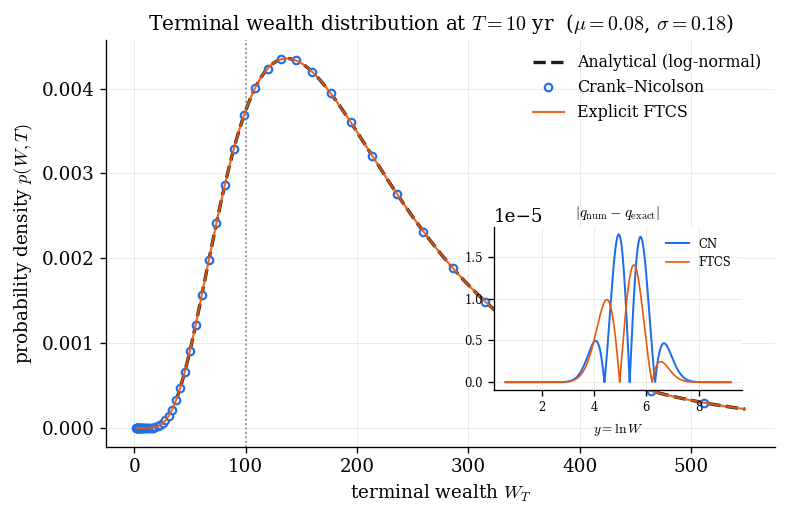

In [ ]:
W = np.exp(y)
def to_wealth_density(q, y):
    """Change of variables: p(W) = q(ln W) / W."""
    return q / np.exp(y)

pT_ana = to_wealth_density(qT_ana, y)
pT_cn  = to_wealth_density(qT_cn,  y)
pT_exp = to_wealth_density(qT_exp, y)

fig, ax = plt.subplots(figsize=(7.2, 4.4))
m = W <= 550
ax.plot(W[m], pT_ana[m], color=C_ANA, ls="--", lw=2.0, label="Analytical (log-normal)")
ax.plot(W[m][::18], pT_cn[m][::18], color=C_CN, ls="none", marker="o", ms=4.5,
        mfc="white", mew=1.3, label="Crank–Nicolson")
ax.plot(W[m], pT_exp[m], color=C_EXP, lw=1.3, alpha=0.9, label="Explicit FTCS")
ax.axvline(W0, color="0.5", lw=1, ls=":")
ax.set_xlabel(r"terminal wealth $W_T$")
ax.set_ylabel(r"probability density $p(W,T)$")
ax.set_title(rf"Terminal wealth distribution at $T={T:.0f}$ yr  ($\mu={mu}$, $\sigma={sigma}$)")
ax.legend(frameon=False, loc="upper right")
fig.savefig("figures/scheme_validation.pdf")
plt.show()

## 5. Spatial convergence of the schemes
We verify spatial accuracy by refining the grid and measuring the max-norm error against
the exact Gaussian. For **Crank–Nicolson** (unconditionally stable) we hold the time step
fixed and small ($\Delta t = 2\times10^{-3}$) so the $\mathcal{O}(\Delta t^2)$ temporal
error is negligible and the *spatial* order is isolated cleanly; the error then decays as
$\mathcal{O}(\Delta y^2)$. For the **explicit FTCS** scheme stability *forces*
$\Delta t\propto\Delta y^2$ (the diffusion number must stay $\le\tfrac12$), so its temporal
and spatial errors shrink together and the total also scales as $\mathcal{O}(\Delta y^2)$.
(Coupling $\Delta t\propto\Delta y$ for CN instead makes the equal-order temporal and
spatial truncation terms cancel intermittently, producing a non-monotone error that
obscures the underlying second order — hence the fixed-$\Delta t$ design here.)
A slightly enlarged $t_0=0.25$ keeps the initial Gaussian resolved on the coarsest grid.

grid refinement — max-norm error vs exact Gaussian:
  CN    N=  201  dy=0.04303  err=1.1115e-03
  CN    N=  401  dy=0.02152  err=2.7797e-04
  CN    N=  801  dy=0.01076  err=6.9448e-05
  CN    N= 1601  dy=0.00538  err=1.7358e-05
  CN    N= 3201  dy=0.00269  err=4.3375e-06
  FTCS  N=  201  dy=0.04303  err=1.2521e-03
  FTCS  N=  401  dy=0.02152  err=2.1572e-04
  FTCS  N=  801  dy=0.01076  err=5.6226e-05
  FTCS  N= 1601  dy=0.00538  err=1.3501e-05
observed spatial order  Crank–Nicolson ≈ 2.00
observed order          Explicit FTCS  ≈ 2.15


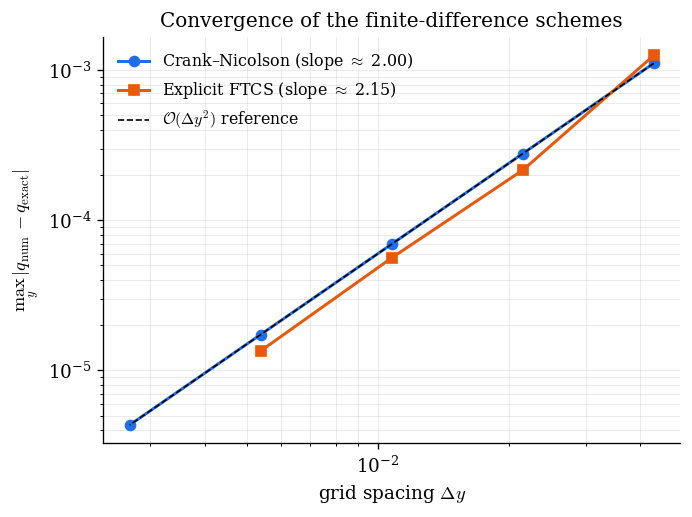

In [7]:
t0c = 0.25
Ns_cn  = [201, 401, 801, 1601, 3201]
Ns_exp = [201, 401, 801, 1601]
DT_CN_FIXED = 2e-3                       # small enough that temporal error is negligible

def conv_errors(Ns, scheme):
    hs, es = [], []
    for N in Ns:
        yN  = make_loggrid(W0, mu, sigma, T, n_std=7.0, N=N)
        h   = yN[1] - yN[0]
        q0N = initial_condition(yN, W0, mu, sigma, t0c)
        anaN = gauss_logdensity(yN, T, W0, mu, sigma)
        if scheme == "cn":
            qN, _ = solve_cn(yN, q0N, nu, sigma, t0c, T, dt=DT_CN_FIXED)
        else:
            qN, _ = solve_explicit(yN, q0N, nu, sigma, t0c, T, dt=0.4*h**2/sigma**2)
        hs.append(h)
        es.append(np.max(np.abs(qN - anaN)))
    return np.array(hs), np.array(es)

h_cn,  e_cn_c  = conv_errors(Ns_cn,  "cn")
h_exp, e_exp_c = conv_errors(Ns_exp, "exp")
slope_cn  = np.polyfit(np.log(h_cn),  np.log(e_cn_c),  1)[0]
slope_exp = np.polyfit(np.log(h_exp), np.log(e_exp_c), 1)[0]
print("grid refinement — max-norm error vs exact Gaussian:")
for N, h, e in zip(Ns_cn, h_cn, e_cn_c):
    print(f"  CN    N={N:5d}  dy={h:.5f}  err={e:.4e}")
for N, h, e in zip(Ns_exp, h_exp, e_exp_c):
    print(f"  FTCS  N={N:5d}  dy={h:.5f}  err={e:.4e}")
print(f"observed spatial order  Crank–Nicolson ≈ {slope_cn:.2f}")
print(f"observed order          Explicit FTCS  ≈ {slope_exp:.2f}")

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.loglog(h_cn,  e_cn_c,  "o-", color=C_CN,
          label=fr"Crank–Nicolson (slope $\approx$ {slope_cn:.2f})")
ax.loglog(h_exp, e_exp_c, "s-", color=C_EXP,
          label=fr"Explicit FTCS (slope $\approx$ {slope_exp:.2f})")
ax.loglog(h_cn, e_cn_c[-1]*(h_cn/h_cn[-1])**2, "k--", lw=1,
          label=r"$\mathcal{O}(\Delta y^2)$ reference")
ax.set_xlabel(r"grid spacing $\Delta y$")
ax.set_ylabel(r"$\max_y\,|q_{\mathrm{num}} - q_{\mathrm{exact}}|$")
ax.set_title("Convergence of the finite-difference schemes")
ax.legend(frameon=False)
ax.grid(True, which="both", alpha=0.25)
fig.savefig("figures/convergence.pdf")
plt.show()

## 6. Monte-Carlo cross-check and sample paths
An independent confirmation by simulating the SDE. Since log-wealth is exactly Gaussian,
the terminal sample is drawn in a single step; a handful of trajectories are shown for
intuition, with the analytic median and mean overlaid.

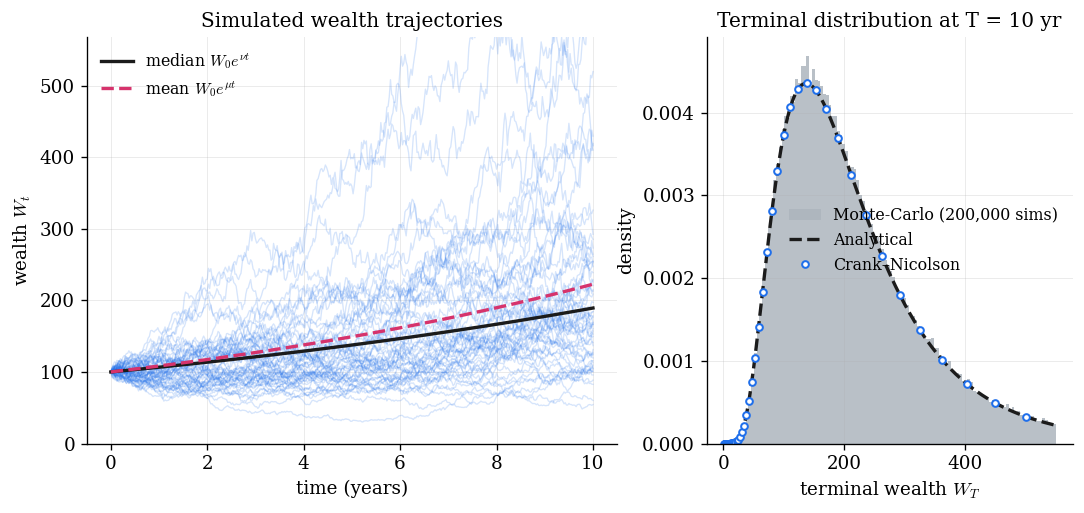

In [8]:
n_sims = 200_000
WT_mc = W0*np.exp(nu*T + sigma*np.sqrt(T)*rng.standard_normal(n_sims))

n_show, n_steps = 60, 400
tgrid = np.linspace(0.0, T, n_steps+1)
dtp = T/n_steps
incr = nu*dtp + sigma*np.sqrt(dtp)*rng.standard_normal((n_show, n_steps))
logpaths = np.log(W0) + np.concatenate([np.zeros((n_show, 1)), np.cumsum(incr, axis=1)], axis=1)
paths = np.exp(logpaths)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.6, 4.4),
                               gridspec_kw={"width_ratios": [1.45, 1.0]})
for i in range(n_show):
    axL.plot(tgrid, paths[i], color=C_CN, alpha=0.18, lw=0.8)
axL.plot(tgrid, W0*np.exp(nu*tgrid), color=C_ANA, lw=2, label=r"median $W_0e^{\nu t}$")
axL.plot(tgrid, W0*np.exp(mu*tgrid), color=C_AGG, lw=2, ls="--", label=r"mean $W_0e^{\mu t}$")
axL.set_xlabel("time (years)")
axL.set_ylabel(r"wealth $W_t$")
axL.set_title("Simulated wealth trajectories")
axL.legend(frameon=False)
axL.set_ylim(0, np.percentile(paths, 99.0))

m = W <= 550
axR.hist(WT_mc, bins=120, range=(0, 550), density=True, color=C_MC, alpha=0.85,
         label=f"Monte-Carlo ({n_sims:,} sims)")
axR.plot(W[m], pT_ana[m], color=C_ANA, ls="--", lw=2, label="Analytical")
axR.plot(W[m][::20], pT_cn[m][::20], color=C_CN, ls="none", marker="o", ms=4,
         mfc="white", mew=1.2, label="Crank–Nicolson")
axR.set_xlabel(r"terminal wealth $W_T$")
axR.set_ylabel("density")
axR.set_title(f"Terminal distribution at T = {T:.0f} yr")
axR.legend(frameon=False)
fig.savefig("figures/paths_terminal.pdf")
plt.show()

## 7. Propagation of the wealth density
The headline picture: an (almost) point mass at $W_0$ spreads and skews into the terminal
log-normal as time advances. Snapshots are recorded directly from the Crank–Nicolson march.

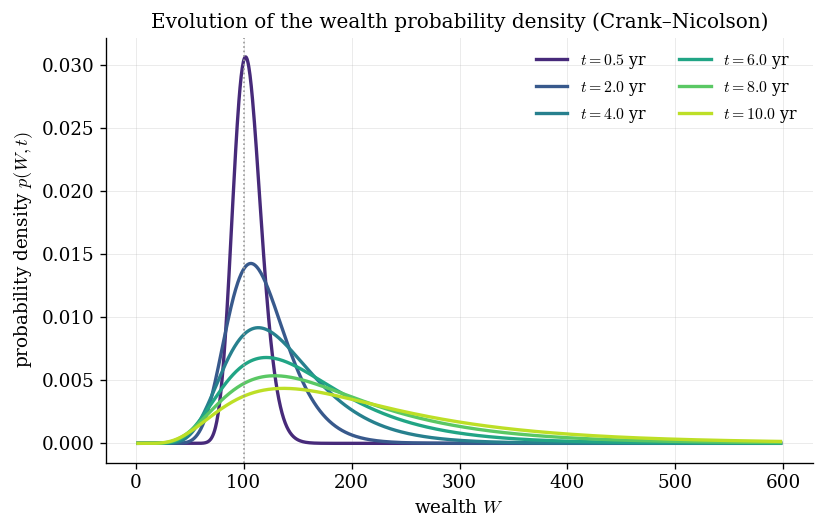

In [9]:
rec = [0.5, 2.0, 4.0, 6.0, 8.0, 10.0]
_, snaps = solve_cn(y, q0.copy(), nu, sigma, t0, T, dt=0.01, record_times=rec)

fig, ax = plt.subplots(figsize=(7.6, 4.6))
colors = plt.cm.viridis(np.linspace(0.12, 0.9, len(rec)))
Wm = np.exp(y)
m = Wm <= 600
for c, (tt, qq) in zip(colors, sorted(snaps.items())):
    ax.plot(Wm[m], (qq/Wm)[m], color=c, lw=2, label=fr"$t={tt:.1f}$ yr")
ax.axvline(W0, color="0.6", ls=":", lw=1)
ax.set_xlabel(r"wealth $W$")
ax.set_ylabel(r"probability density $p(W,t)$")
ax.set_title("Evolution of the wealth probability density (Crank–Nicolson)")
ax.legend(frameon=False, ncol=2)
fig.savefig("figures/density_evolution.pdf")
plt.show()

## 8. Risk metrics from the propagated density
Because we have the *full* density — not just its moments — goal-attainment and tail-risk
measures follow by quadrature. We renormalise the terminal density to remove any tiny
truncation drift, then compare the numbers to the closed form.

In [10]:
def metrics_from_density(y, q, W0, goal, floor, alpha=0.05):
    """Goal/tail metrics computed numerically from a density q on the log-grid y."""
    q = q / np.trapezoid(q, y)                                  # renormalise
    cdf = np.concatenate([[0.0], cumulative_trapezoid(q, y)])   # P(Y <= y)
    W = np.exp(y)
    Pleq = lambda level: np.interp(np.log(level), y, cdf)       # P(W_T <= level)
    p_goal  = 1.0 - Pleq(goal)
    p_floor = Pleq(floor)
    p_loss  = Pleq(W0)
    yq = np.interp(alpha, cdf, y)                               # alpha-quantile (log)
    var_w = np.exp(yq)
    part = np.concatenate([[0.0], cumulative_trapezoid(W*q, y)])   # ∫ e^y q dy
    es_w = np.interp(yq, y, part) / alpha                       # E[W | W <= VaR]
    mean = np.trapezoid(W*q, y)
    return dict(p_goal=p_goal, p_floor=p_floor, p_loss=p_loss,
                var_w=var_w, es_w=es_w,
                var_loss=(W0-var_w)/W0, es_loss=(W0-es_w)/W0, mean=mean)

num = metrics_from_density(y, qT_cn, W0, GOAL, FLOOR)
ana = analytic_metrics(W0, mu, sigma, T, GOAL, FLOOR)
print(f"{'metric':24s}{'FDM (CN)':>13s}{'analytical':>13s}")
for k, lab in [('p_goal', 'P(W_T >= 200)'), ('p_loss', 'P(W_T < 100)'),
               ('p_floor', 'P(W_T <= 80)'), ('var_w', '5% VaR wealth'),
               ('es_w', '5% ES wealth'), ('mean', 'E[W_T]')]:
    print(f"{lab:24s}{num[k]:13.4f}{ana[k]:13.4f}")

metric                       FDM (CN)   analytical
P(W_T >= 200)                  0.4614       0.4614
P(W_T < 100)                   0.1312       0.1312
P(W_T <= 80)                   0.0652       0.0652
5% VaR wealth                 74.2105      74.2103
5% ES wealth                  59.7016      59.6988
E[W_T]                       222.5549     222.5541


## 9. Comparing asset allocations
A portfolio places weight $w$ in equity and $1-w$ in the risk-free asset, giving
$\mu_p = w\mu_e + (1-w)r_f$ and $\sigma_p = w\sigma_e$. We solve the Fokker–Planck equation
for three archetypes and read off their risk profiles on a common grid.

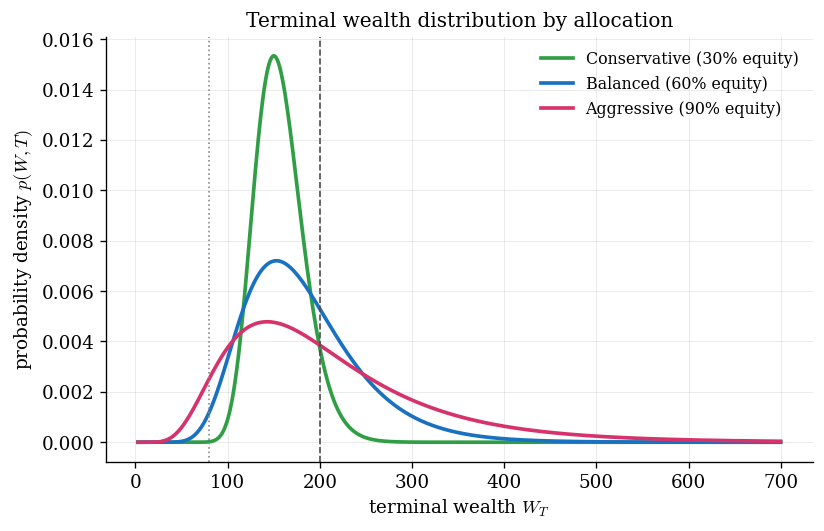

Allocation       mu_p  sig_p  P(goal)  P(loss)   5%VaR    5%ES
Conservative    0.045  0.054    0.066    0.005   116.7   108.9
Balanced        0.060  0.108    0.329    0.056    98.0    85.6
Aggressive      0.075  0.162    0.442    0.114    79.9    65.6


In [11]:
allocs = [("Conservative", 0.30, C_CONS),
          ("Balanced",     0.60, C_BAL),
          ("Aggressive",   0.90, C_AGG)]

def alloc_params(w):
    return w*MU_EQ + (1.0 - w)*RF, w*SIG_EQ

# Common grid that comfortably spans all three allocations
los, his = [], []
for _, w, _ in allocs:
    mp, sp = alloc_params(w)
    yy = make_loggrid(W0, mp, sp, T, n_std=7.0, N=1601)
    los.append(yy[0]); his.append(yy[-1])
yc = np.linspace(min(los), max(his), 2001)
Wc = np.exp(yc)

fig, ax = plt.subplots(figsize=(7.6, 4.6))
m = Wc <= 700
rows = []
for name, w, col in allocs:
    mp, sp = alloc_params(w)
    nup = log_drift(mp, sp)
    q0c = gauss_logdensity(yc, t0, W0, mp, sp)
    qTc, _ = solve_cn(yc, q0c, nup, sp, t0, T, dt=0.01)
    ax.plot(Wc[m], (qTc/Wc)[m], color=col, lw=2.2, label=f"{name} ({int(w*100)}% equity)")
    rows.append((name, mp, sp, metrics_from_density(yc, qTc, W0, GOAL, FLOOR)))
ax.axvline(GOAL,  color="0.30", ls="--", lw=1)
ax.axvline(FLOOR, color="0.55", ls=":",  lw=1)
ax.set_xlabel(r"terminal wealth $W_T$")
ax.set_ylabel(r"probability density $p(W,T)$")
ax.set_title("Terminal wealth distribution by allocation")
ax.legend(frameon=False)
fig.savefig("figures/allocation_densities.pdf")
plt.show()

print(f"{'Allocation':14s}{'mu_p':>7s}{'sig_p':>7s}{'P(goal)':>9s}{'P(loss)':>9s}{'5%VaR':>8s}{'5%ES':>8s}")
for name, mp, sp, mt in rows:
    print(f"{name:14s}{mp:7.3f}{sp:7.3f}{mt['p_goal']:9.3f}{mt['p_loss']:9.3f}{mt['var_w']:8.1f}{mt['es_w']:8.1f}")

## 10. The risk–reward trade-off across allocations
Sweeping the equity weight $w$ traces how the probability of hitting the goal and the
downside (5th-percentile terminal wealth) move together. The FDM markers sit on the
analytical curves, closing the loop between the PDE solver and the closed-form law.

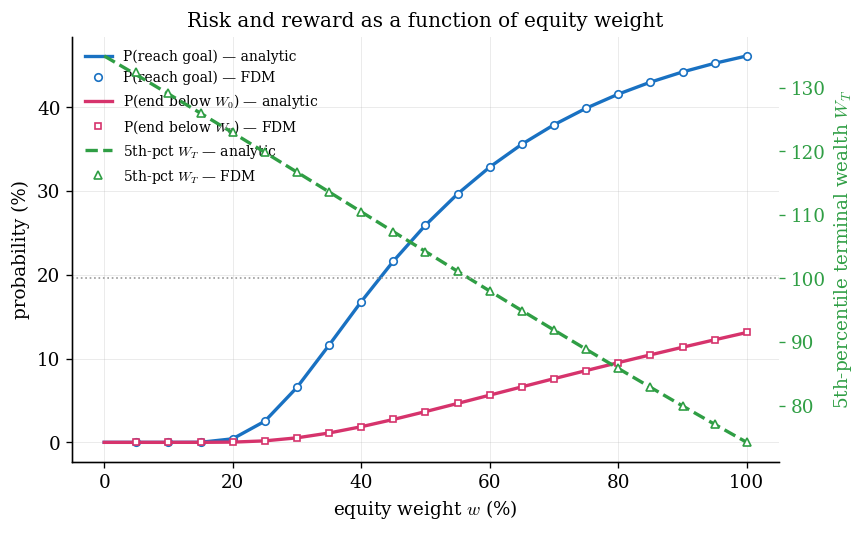

In [12]:
ws = np.linspace(0.0, 1.0, 21)
pg_fdm, pl_fdm, q5_fdm = [], [], []
pg_an,  pl_an,  q5_an  = [], [], []
ysw = np.linspace(min(los) - 0.5, max(his) + 0.5, 1201)
for w in ws:
    mp, sp = alloc_params(w)
    a = analytic_metrics(W0, mp, max(sp, 1e-9), T, GOAL, FLOOR)
    pg_an.append(a['p_goal']*100); pl_an.append(a['p_loss']*100); q5_an.append(a['var_w'])
    if sp < 1e-9:
        pg_fdm.append(np.nan); pl_fdm.append(np.nan); q5_fdm.append(np.nan)
    else:
        nup = log_drift(mp, sp)
        q0c = gauss_logdensity(ysw, t0, W0, mp, sp)
        qTc, _ = solve_cn(ysw, q0c, nup, sp, t0, T, dt=0.01)
        mt = metrics_from_density(ysw, qTc, W0, GOAL, FLOOR)
        pg_fdm.append(mt['p_goal']*100); pl_fdm.append(mt['p_loss']*100); q5_fdm.append(mt['var_w'])

fig, ax1 = plt.subplots(figsize=(7.6, 4.6))
ax1.plot(ws*100, pg_an, color=C_BAL, lw=2, label="P(reach goal) — analytic")
ax1.plot(ws*100, pg_fdm, "o", color=C_BAL, ms=4.5, mfc="white", label="P(reach goal) — FDM")
ax1.plot(ws*100, pl_an, color=C_AGG, lw=2, label=r"P(end below $W_0$) — analytic")
ax1.plot(ws*100, pl_fdm, "s", color=C_AGG, ms=4, mfc="white", label=r"P(end below $W_0$) — FDM")
ax1.set_xlabel(r"equity weight $w$ (%)")
ax1.set_ylabel("probability (%)")
ax2 = ax1.twinx()
ax2.grid(False)
ax2.plot(ws*100, q5_an, color=C_CONS, lw=2, ls="--", label="5th-pct $W_T$ — analytic")
ax2.plot(ws*100, q5_fdm, "^", color=C_CONS, ms=4.5, mfc="white", label="5th-pct $W_T$ — FDM")
ax2.axhline(W0, color="0.6", lw=1, ls=":")
ax2.set_ylabel(r"5th-percentile terminal wealth $W_T$", color=C_CONS)
ax2.tick_params(axis='y', colors=C_CONS)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, frameon=False, fontsize=8.3, loc="upper left")
ax1.set_title("Risk and reward as a function of equity weight")
fig.savefig("figures/allocation_sweep.pdf")
plt.show()

## 11. Conclusions
The Fokker–Planck equation propagates the *entire* probability density of portfolio
wealth, not merely its mean and variance. A Crank–Nicolson finite-difference solver on the
log-transformed (constant-coefficient) equation reproduces the closed-form log-normal law
to second order and agrees with Monte-Carlo simulation. From the propagated terminal
density we extract goal-attainment probabilities, Value-at-Risk, and Expected Shortfall by
simple quadrature, and we compare asset allocations on a common footing. The framework
extends naturally to settings with no closed form — time-dependent or state-dependent
drift/volatility, and (in higher dimensions) multi-asset portfolios — which is precisely
where a PDE solver earns its keep.
print("Done.")